## **BITS Pilani – M.Tech in Data Science**

### **Subject:** Fair Accountable Transparent Machine Learning  
### **Course Code:** S2-24_AIMLCZG517  
### **Assignment 1:** Fairness in Loan Approval Prediction  

### **Group Members:**  
#### 1. Amulya Gupta - 2024AB05200  
#### 2. Prafull Ranjan - 2024aa05207  
#### 3. Akash Shivadas Chatake - 2024AB05226   

### **Submission Date:** 15th June 2025




In [1]:
  !pip install fairlearn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 3.8 MB/s eta 0:00:00


In [2]:
!pip install aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 3.7 MB/s eta 0:00:00


## Load the dataset

Load the loan approval dataset from a CSV file into a pandas DataFrame.

**Reasoning**:
Import pandas and load the CSV file into a DataFrame, then display the first few rows.




In [3]:
from google.colab import files
import pandas as pd
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))
  # Assuming the uploaded file is a CSV, read it into a pandas DataFrame
  try:
    df = pd.read_csv(fn)
    print("\nDataFrame created successfully:")
    display(df.head())
  except Exception as e:
    print(f"Error reading file {fn}: {e}")

Saving clean_dataset(1).csv to clean_dataset(1).csv
User uploaded file "clean_dataset(1).csv" with length 47107 bytes

DataFrame created successfully:


,Gender,Age,Debt,Married,BankCustomer,Industry,Ethnicity,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,Citizen,ZipCode,Income,Approved
0,1,30.83,0.000,1,1,Industrials,White,1.25,1,1,1,0,ByBirth,202,0,1
1,0,58.67,4.460,1,1,Materials,Black,3.04,1,1,6,0,ByBirth,43,560,1
2,0,24.50,0.500,1,1,Materials,Black,1.50,1,0,0,0,ByBirth,280,824,1
3,1,27.83,1.540,1,1,Industrials,White,3.75,1,1,5,1,ByBirth,100,3,1
4,1,20.17,5.625,1,1,Industrials,White,1.71,1,0,0,0,ByOtherMeans,120,0,1


# Task 1 – Exploratory Data Analysis (EDA)

In this section we will:

1. Inspect the raw dataset  
2. Quantify missingness  
3. Perform **univariate** analysis of each feature and the target  
4. Perform **bivariate** analysis to see how features relate to Approval and to Gender  
5. Look at simple multivariate structure via correlations  

**Fairness lens:** Whenever we segment or color by the target variable (Approved), we'll also facet or apply color by the protected attribute (Gender) to make any disparities clearly visible.



## 1. Inspect the dataset

**Goal:** Confirm what columns we have, their types, and overall shape.  
**Why:** We know which variables are numeric vs. categorical, and can plan the rest of our plots accordingly.


In [4]:
# 1.1 Overview
print("Shape:", df.shape)
print("\nColumn names & types:")
print(df.dtypes)
# 1.2 Description
df.describe()

Shape: (690, 16)

Column names & types:
Gender              int64
Age               float64
Debt              float64
Married             int64
BankCustomer        int64
Industry           object
Ethnicity          object
YearsEmployed     float64
PriorDefault        int64
Employed            int64
CreditScore         int64
DriversLicense      int64
Citizen            object
ZipCode             int64
Income              int64
Approved            int64
dtype: object


,Gender,Age,Debt,Married,BankCustomer,YearsEmployed,PriorDefault,Employed,CreditScore,DriversLicense,ZipCode,Income,Approved
count,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.000000,690.00000,690.000000,690.000000,690.000000,690.000000
mean,0.695652,31.514116,4.758725,0.760870,0.763768,2.223406,0.523188,0.427536,2.40000,0.457971,180.547826,1017.385507,0.444928
std,0.460464,11.860245,4.978163,0.426862,0.425074,3.346513,0.499824,0.495080,4.86294,0.498592,173.970323,5210.102598,0.497318
min,0.000000,13.750000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,22.670000,1.000000,1.000000,1.000000,0.165000,0.000000,0.000000,0.00000,0.000000,60.000000,0.000000,0.000000
50%,1.000000,28.460000,2.750000,1.000000,1.000000,1.000000,1.000000,0.000000,0.00000,0.000000,160.000000,5.000000,0.000000
75%,1.000000,37.707500,7.207500,1.000000,1.000000,2.625000,1.000000,1.000000,3.00000,1.000000,272.000000,395.500000,1.000000
max,1.000000,80.250000,28.000000,1.000000,1.000000,28.500000,1.000000,1.000000,67.00000,1.000000,2000.000000,100000.000000,1.000000


## 2. Quantify missing values (result)

**Goal:** Check for any NaNs before plotting.  



In [5]:
# Re-run the missing-value check to document in notebook:
missing_pct = df.isnull().mean() * 100
if missing_pct.sum() == 0:
    print("✅ No missing values detected—proceeding with EDA.")
else:
    display(missing_pct[missing_pct>0].to_frame("Missing %"))

✅ No missing values detected—proceeding with EDA.


## 3. Univariate analysis

We’ll now look at each feature on its own to understand its distribution.


### 3.1 Target distribution

**Goal:** See how imbalanced the `Approved` outcome is.  
**What you’ll see:** Bar chart of approved vs. not approved, plus the numeric rate.


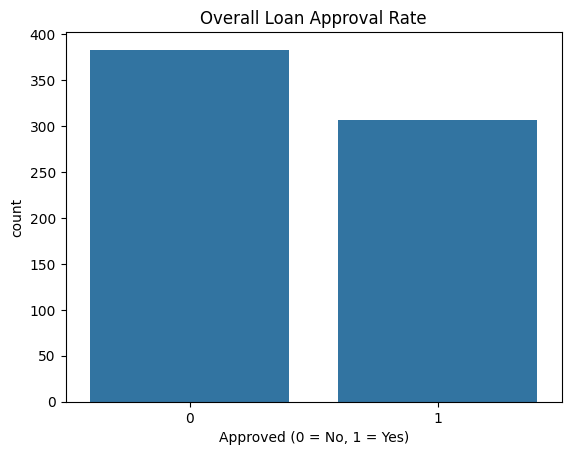

Overall approval rate: 44.49%


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots()
sns.countplot(x="Approved", data=df, ax=ax)
ax.set_title("Overall Loan Approval Rate")
ax.set_xlabel("Approved (0 = No, 1 = Yes)")
plt.show()

print(f"Overall approval rate: {df['Approved'].mean():.2%}")

### 3.2 Protected attribute distribution

**Goal:** Check balance of our protected attribute (`Gender`).  
**What you’ll see:** Count of Male vs. Female applicants.


<ipython-input-7-1621835916>:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Female (0)", "Male (1)"])


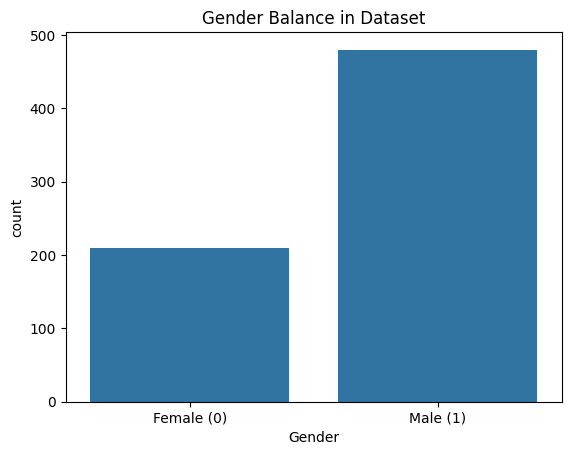

Gender             1         0
Proportion  0.695652  0.304348


In [7]:
fig, ax = plt.subplots()
sns.countplot(x="Gender", data=df, ax=ax)
ax.set_xticklabels(["Female (0)", "Male (1)"])
ax.set_title("Gender Balance in Dataset")
plt.show()

print(df["Gender"].value_counts(normalize=True).rename("Proportion").to_frame().T)

### 3.3 Numeric feature distributions

**Goal:** Visualize each numeric column’s histogram and boxplot to spot skew/outliers.  
**Which —** All `int64`/`float64` except `Approved` & `Gender`.


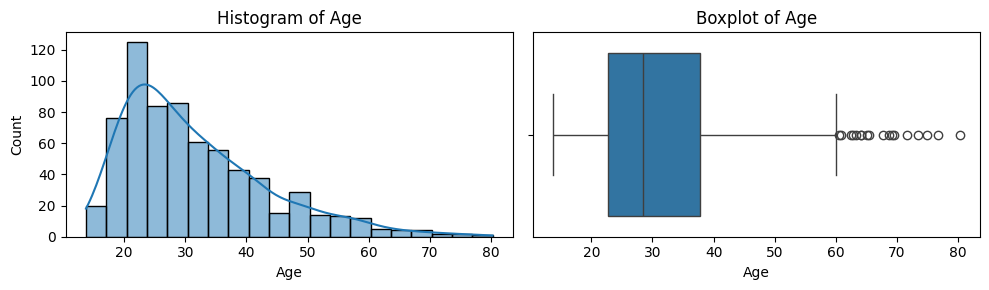

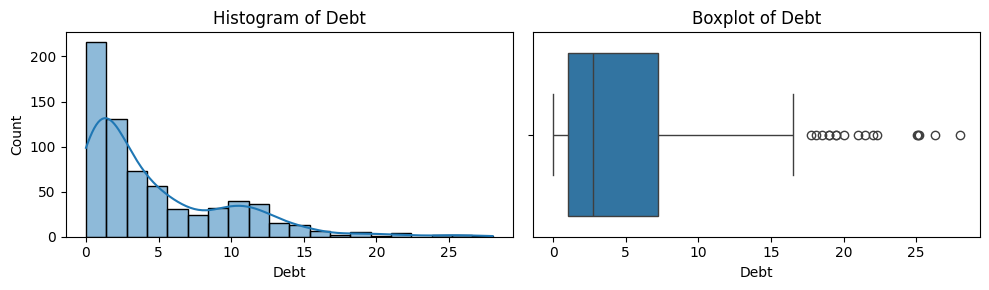

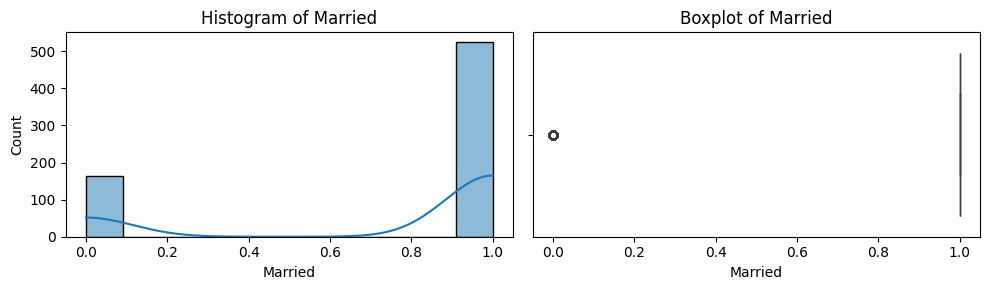

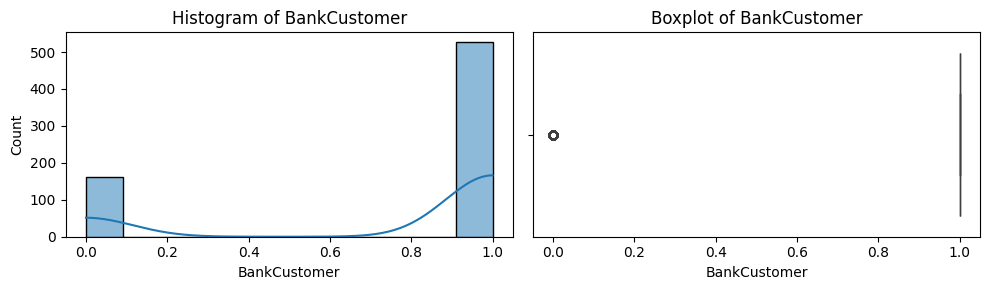

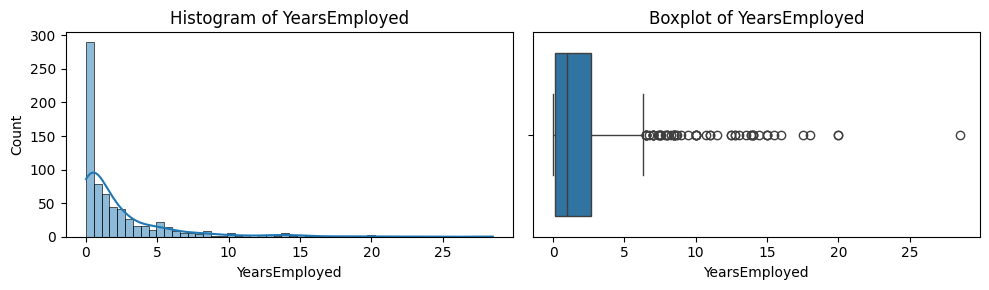

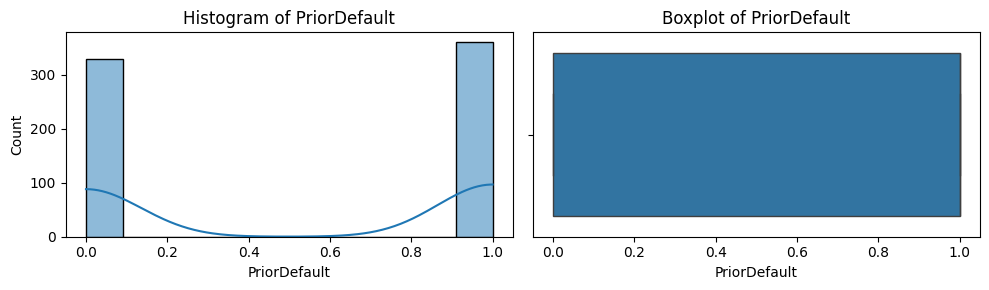

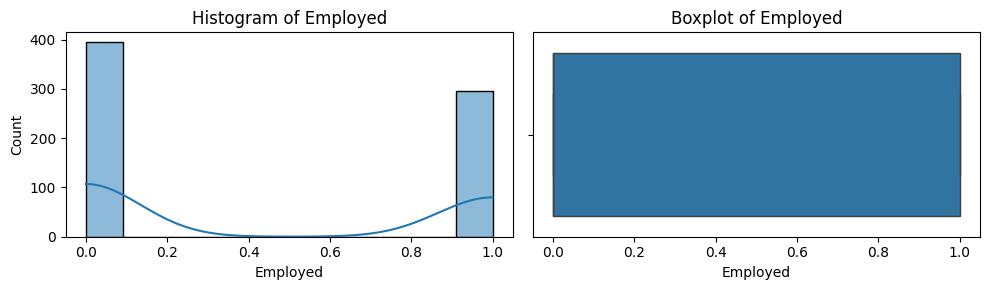

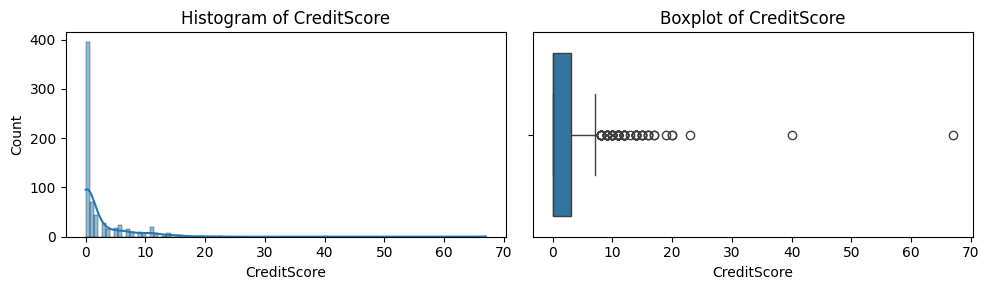

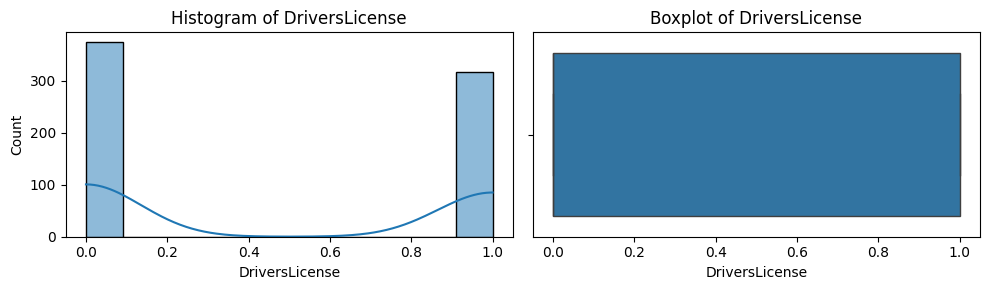

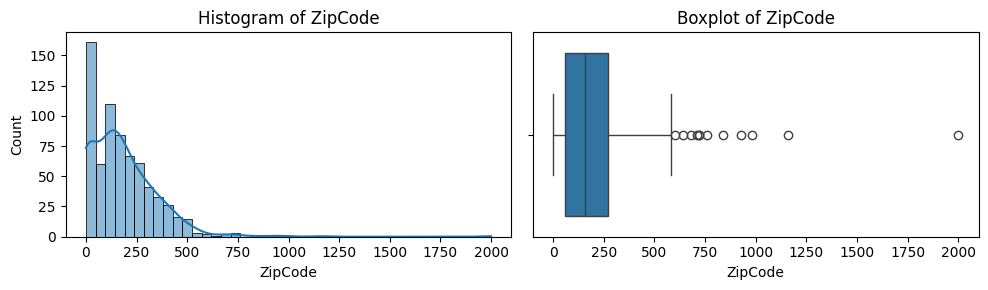

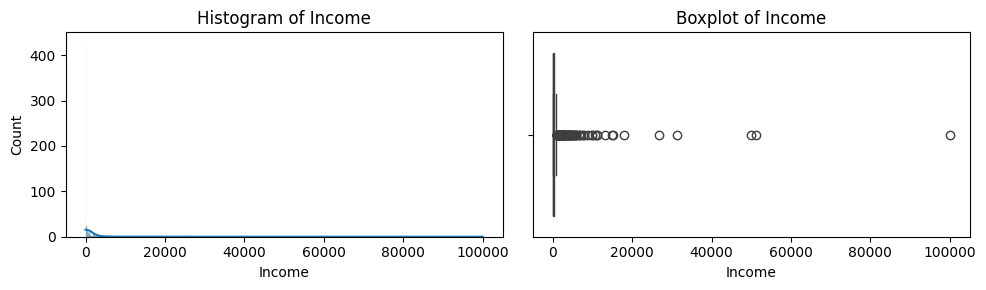

In [8]:
num_cols = df.select_dtypes(include=["int64","float64"]).drop(columns=["Approved","Gender"]).columns

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(10, 3))
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f"Histogram of {col}")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"Boxplot of {col}")
    plt.tight_layout()
    plt.show()

### 3.4 Categorical feature counts

**Goal:** Count each category in the text/object columns.  
**Which —** `Industry`, `Ethnicity`, `Citizen`.


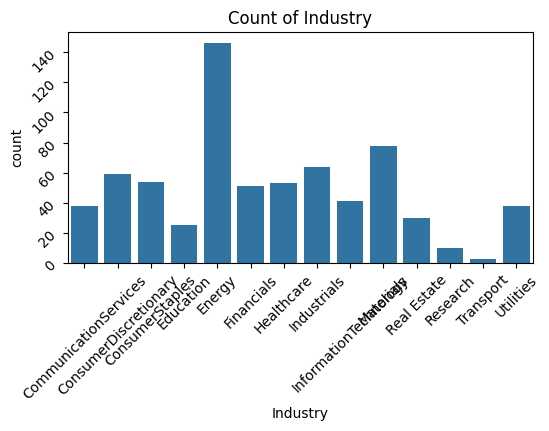

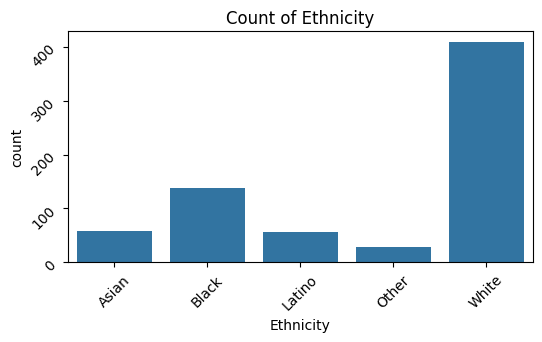

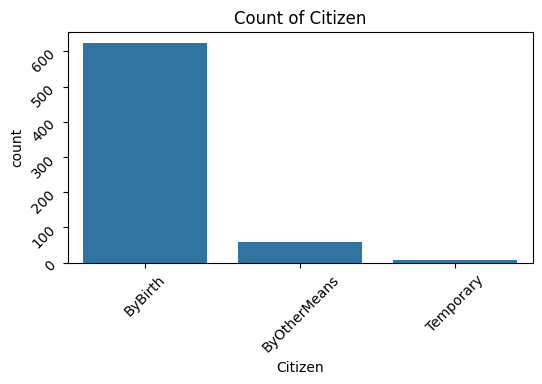

In [9]:
cat_cols = ["Industry","Ethnicity","Citizen"]

for col in cat_cols:
    fig, ax = plt.subplots(figsize=(6,3))
    sns.countplot(x=col, data=df, order=sorted(df[col].unique()), ax=ax)
    ax.set_title(f"Count of {col}")
    ax.tick_params(rotation=45)
    plt.show()

## 4. Bivariate analysis

Next, we’ll see how each feature interacts **with** the target **and** with gender.


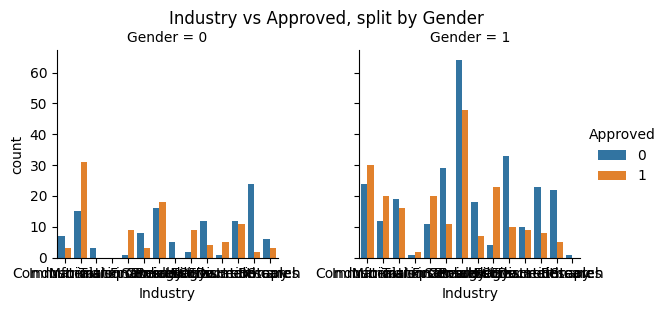

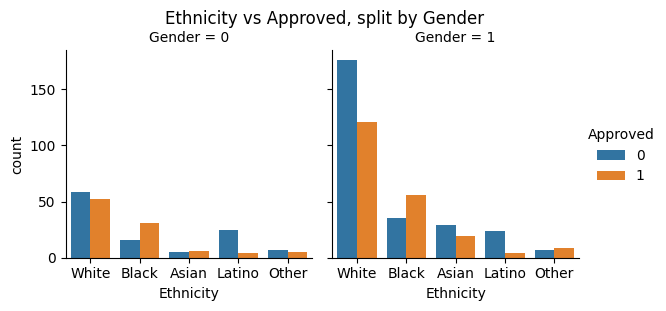

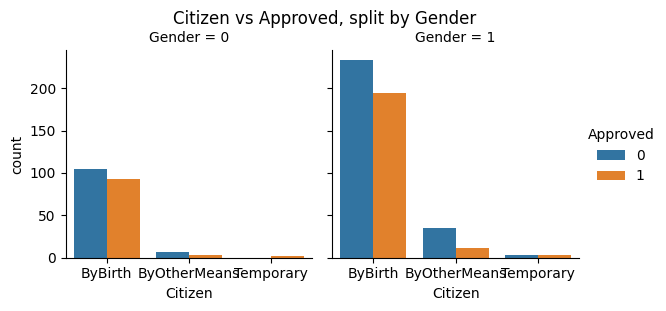

In [10]:
for col in cat_cols:
    g = sns.catplot(x=col, hue="Approved", col="Gender",
                    data=df, kind="count", height=3, aspect=1)
    g.fig.suptitle(f"{col} vs Approved, split by Gender", y=1.02)
    plt.show()

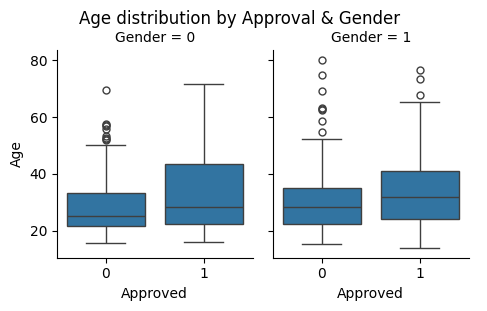

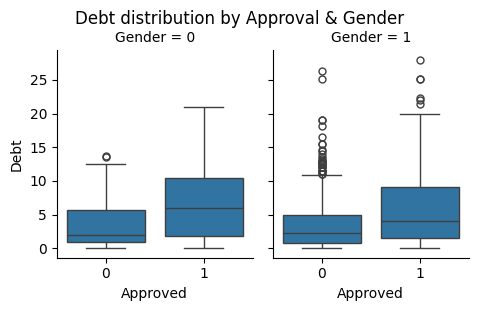

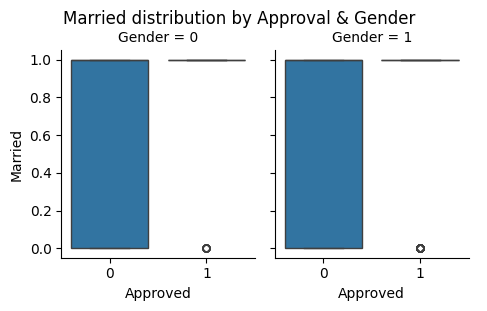

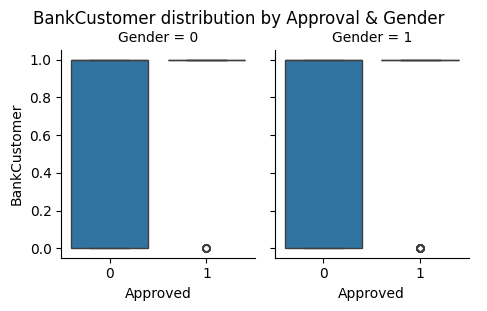

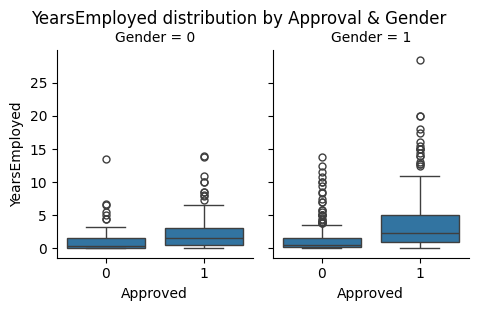

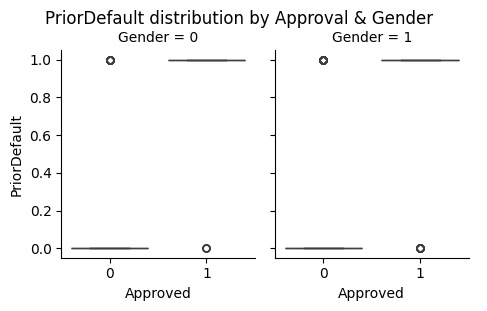

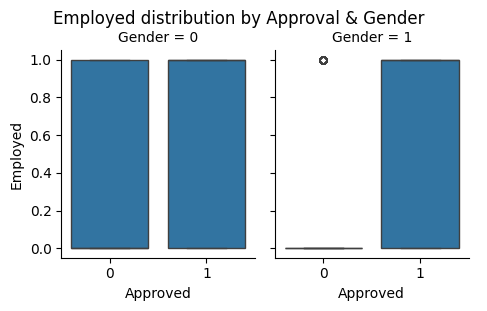

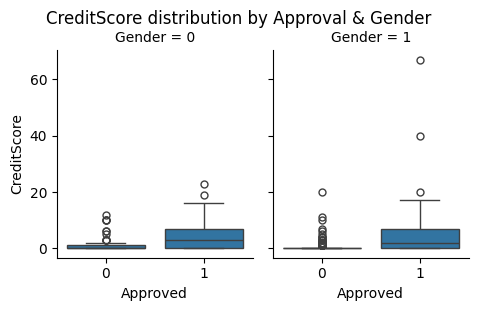

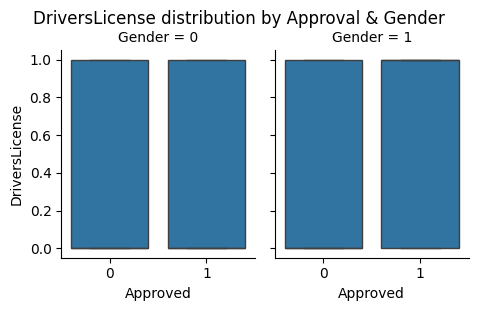

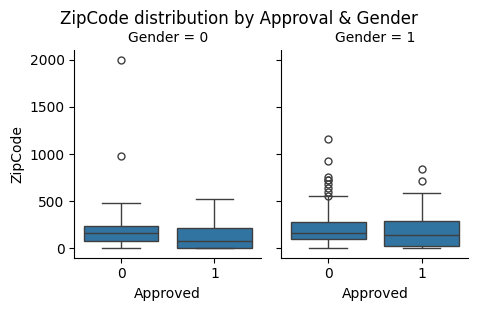

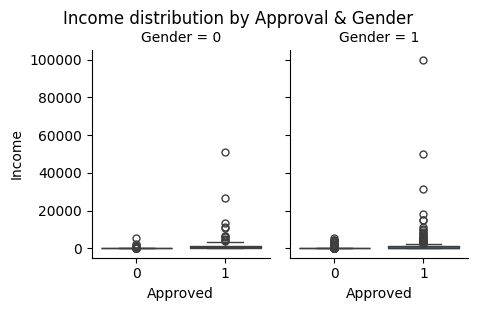

In [11]:
for col in num_cols:
    g = sns.catplot(x="Approved", y=col, col="Gender",
                    data=df, kind="box", height=3, aspect=0.8)
    g.fig.suptitle(f"{col} distribution by Approval & Gender", y=1.02)
    plt.show()

## 5. Multivariate glance: correlation

**Goal:** Spot any strong linear relationships among numeric features (potential proxies).  
**What you’ll see:** A heatmap of Pearson correlations.


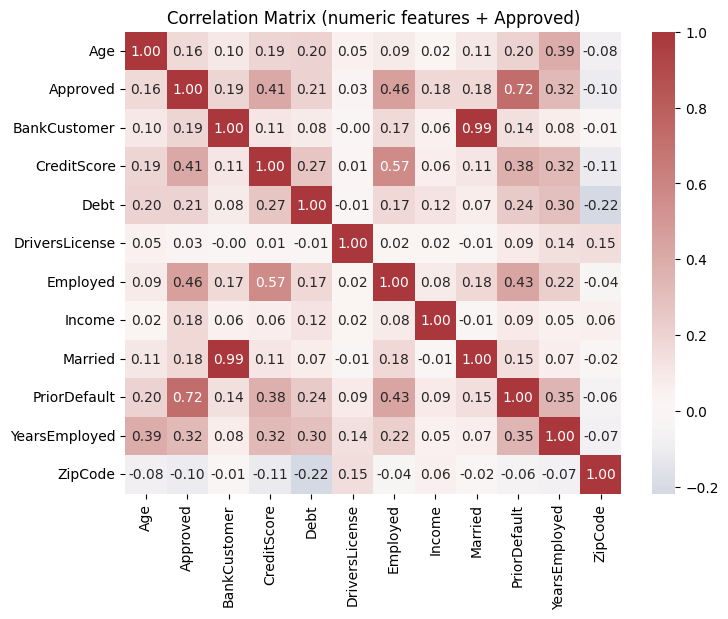

In [12]:
corr = df[num_cols.union(["Approved"])].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", center=0, cmap="vlag")
plt.title("Correlation Matrix (numeric features + Approved)")
plt.show()

## Task 1 Summary

From our correlation heatmap of all numeric features (plus **Approved**):

- **Top predictors of approval**  
  - **PriorDefault (ρ ≈ 0.72)** shows the strongest linear relationship with **Approved**.  
  - **Employed (ρ ≈ 0.46)** and **CreditScore (ρ ≈ 0.41)** are the next most predictive.  
  - **YearsEmployed (ρ ≈ 0.32)** and **Age (ρ ≈ 0.20)** also carry moderate signal.

- **Weak or negligible predictors**  
  - **DriversLicense** (ρ ≈ 0.03) and **ZipCode** (ρ ≈ –0.10) correlate very little with the outcome.  
  - **Income** (ρ ≈ 0.18) and **Debt** (ρ ≈ 0.21) are only weakly related.

- **Multicollinearity / redundancy**  
  - **Married** and **BankCustomer** correlate at ≈ 0.99—essentially duplicate information.  
  - **Employed** also correlates moderately with **CreditScore** (ρ ≈ 0.57) and **PriorDefault** (ρ ≈ 0.43).

> **Fairness note:** any numeric feature that systematically differs by gender (e.g., if men have higher credit scores or longer employment) will act as an indirect proxy for **Gender**. Even if we drop **Gender** from the model, these correlated features may re-introduce bias downstream.  


## Task 2 – Baseline Naïve Bayes (with Gender)

**Goal:** Train a Gaussian Naïve Bayes classifier on **all features including the protected attribute (`Gender`)**, using 5-fold cross-validation.  
**Why:** This gives us a reference point for both accuracy and group-level fairness when the model has direct access to `Gender`.  
**Metrics:**  
- **Accuracy**  
- **Statistical Parity Difference (SPD)** = P(ŷ=1 | Gender=0) – P(ŷ=1 | Gender=1)  
- **Disparate Impact (DI)** = P(ŷ=1 | Gender=0) ÷ P(ŷ=1 | Gender=1)


In [13]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate

# 2.1 Prepare features and label

X = pd.get_dummies(df.drop(columns=["Approved"]), drop_first=True) # — include everything except the target
y = df["Approved"]
A = df["Gender"]   # protected attribute

# 2.2 Set up 5-fold CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

accs, spd_list, di_list = [], [], []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    # Train
    clf = GaussianNB()
    clf.fit(X.iloc[train_idx], y.iloc[train_idx])

    # Predict
    y_pred = clf.predict(X.iloc[test_idx])
    acc = accuracy_score(y.iloc[test_idx], y_pred)
    accs.append(acc)

    # Fairness metrics via MetricFrame
    mf = MetricFrame(metrics=selection_rate,
                     y_true=y.iloc[test_idx],
                     y_pred=y_pred,
                     sensitive_features=A.iloc[test_idx])

    rates = mf.by_group  # index: 0 (female), 1 (male)
    unpriv, priv = rates[0], rates[1]

    spd_list.append(unpriv - priv)
    di_list.append(unpriv / priv)

    print(f"Fold {fold}:  accuracy = {acc:.3f},  SPD = {unpriv - priv:+.3f},  DI = {unpriv/priv:.3f}")

# 2.3 Aggregate results
results = pd.DataFrame({
    "accuracy": accs,
    "SPD": spd_list,
    "DI": di_list
})
print("\nMean across folds:")
display(results.mean().to_frame().T)


Fold 1:  accuracy = 0.833,  SPD = +0.159,  DI = 1.451
Fold 2:  accuracy = 0.797,  SPD = -0.124,  DI = 0.693
Fold 3:  accuracy = 0.812,  SPD = +0.099,  DI = 1.302
Fold 4:  accuracy = 0.761,  SPD = -0.042,  DI = 0.875
Fold 5:  accuracy = 0.855,  SPD = +0.117,  DI = 1.345

Mean across folds:


,accuracy,SPD,DI
0,0.811594,0.04197,1.133151


## Task 3 – Naïve Bayes **without** the protected attribute (`Gender`)

**Goal:** Train the same Gaussian Naïve Bayes classifier using 5-fold CV, but **drop** `Gender` from the feature set.  
**Why:** This tells us how much unfairness remains when the model no longer sees the sensitive attribute directly.  
**Metrics:**  
- **Accuracy**  
- **Statistical Parity Difference (SPD)** = P(ŷ=1 | Gender=0) – P(ŷ=1 | Gender=1)  
- **Disparate Impact (DI)** = P(ŷ=1 | Gender=0) ÷ P(ŷ=1 | Gender=1)


In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate

# 3.1 Prepare features and label — drop Gender
X3 = pd.get_dummies(df.drop(columns=["Approved", "Gender"]), drop_first=True)
y3 = df["Approved"]
A3 = df["Gender"]   # still our protected attribute for fairness evaluation

# 3.2 5-fold CV
cv3 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc3, spd3, di3 = [], [], []

for fold, (train_idx, test_idx) in enumerate(cv3.split(X3, y3), start=1):
    clf3 = GaussianNB()
    clf3.fit(X3.iloc[train_idx], y3.iloc[train_idx])

    y3_pred = clf3.predict(X3.iloc[test_idx])
    acc_val = accuracy_score(y3.iloc[test_idx], y3_pred)
    acc3.append(acc_val)

    mf3 = MetricFrame(metrics=selection_rate,
                      y_true=y3.iloc[test_idx],
                      y_pred=y3_pred,
                      sensitive_features=A3.iloc[test_idx])

    rates3 = mf3.by_group  # index 0=female, 1=male
    unpriv3, priv3 = rates3[0], rates3[1]

    spd3.append(unpriv3 - priv3)
    di3.append(unpriv3 / priv3)

    print(f"Fold {fold}: accuracy = {acc_val:.3f}, SPD = {unpriv3-priv3:+.3f}, DI = {unpriv3/priv3:.3f}")

# 3.3 Aggregate
results3 = pd.DataFrame({
    "accuracy": acc3,
    "SPD": spd3,
    "DI": di3
})
print("\nMean across folds:")
display(results3.mean().to_frame().T)


Fold 1: accuracy = 0.833, SPD = +0.159, DI = 1.451
Fold 2: accuracy = 0.804, SPD = -0.134, DI = 0.678
Fold 3: accuracy = 0.812, SPD = +0.099, DI = 1.302
Fold 4: accuracy = 0.761, SPD = -0.042, DI = 0.875
Fold 5: accuracy = 0.855, SPD = +0.117, DI = 1.345

Mean across folds:


,accuracy,SPD,DI
0,0.813043,0.040083,1.13


## Task 4 – Pre-processing: Re-weighting

**Goal:** Apply the AIF360 **Reweighing** pre-processor to assign each training instance a weight that balances the joint distribution of **Gender** and **Approved**, then train a GaussianNB with those weights under 5-fold CV.  
**Why:** This shifts the effective training distribution so that “female & approved”, “female & denied”, “male & approved” and “male & denied” are equally represented, reducing disparate treatment without dropping any data.

**Metrics:** Accuracy, Statistical Parity Difference (SPD), Disparate Impact (DI).


In [15]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate
from aif360.datasets import StandardDataset
from aif360.algorithms.preprocessing import Reweighing

# 4.0 One-hot encode all string/categorical columns so df is fully numeric
df_enc = pd.get_dummies(
    df,
    columns=['Industry', 'Ethnicity', 'Citizen'],  # the object-dtype cols
    drop_first=True
)

# 4.1 Build an AIF360 dataset on the encoded DataFrame
aif_data = StandardDataset(
    df_enc,
    label_name='Approved',
    favorable_classes=[1],
    protected_attribute_names=['Gender'],
    privileged_classes=[[1]]    # assuming 1 = male
)

# 4.2 Fit the Reweighing pre-processor
rw = Reweighing(
    unprivileged_groups=[{'Gender': 0}],
    privileged_groups=[{'Gender': 1}]
)
rw.fit(aif_data)
aif_transf = rw.transform(aif_data)
instance_weights = aif_transf.instance_weights # extract instance weights (one per row in df_enc)

# 4.3 Prepare X, y, A for modelling
X = df_enc.drop(columns=['Approved'])
y = df_enc['Approved']
A = df_enc['Gender']

# 4.4 5-fold CV with sample weights
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_rw, spd_rw, di_rw = [], [], []

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    A_test = A.iloc[test_idx]
    w_train = instance_weights[train_idx]

    clf = GaussianNB()
    clf.fit(X_train, y_train, sample_weight=w_train)

    y_pred = clf.predict(X_test)
    acc = accuracy_score(y_test, y_pred)

    mf = MetricFrame(
        metrics=selection_rate,
        y_true=y_test,
        y_pred=y_pred,
        sensitive_features=A_test
    )
    sr = mf.by_group    # sr[0]=female, sr[1]=male
    spd = sr[0] - sr[1]
    di  = sr[0] / sr[1]

    acc_rw.append(acc)
    spd_rw.append(spd)
    di_rw.append(di)

    print(f"Fold {fold}: accuracy={acc:.3f}, SPD={spd:+.3f}, DI={di:.3f}")

# 4.5 Aggregate
import pandas as pd
results_rw = pd.DataFrame({
    'accuracy': acc_rw,
    'SPD': spd_rw,
    'DI': di_rw
})
print("\nMean across folds:")
display(results_rw.mean().to_frame().T)


pip install 'aif360[inFairness]'


Fold 1: accuracy=0.833, SPD=+0.159, DI=1.451
Fold 2: accuracy=0.797, SPD=-0.124, DI=0.693
Fold 3: accuracy=0.812, SPD=+0.069, DI=1.203
Fold 4: accuracy=0.761, SPD=-0.042, DI=0.875
Fold 5: accuracy=0.848, SPD=+0.108, DI=1.308

Mean across folds:


,accuracy,SPD,DI
0,0.810145,0.034017,1.105921


## Task 5 – Pre-processing: Universal Sampling

**Goal:** Resample the training set so that **each (Gender, Approved)** combination has the same number of examples, then train a GaussianNB under 5-fold CV.  
**Why:** This ensures the classifier sees a “balanced” distribution across both gender and outcome, reducing disparate representation without dropping attributes.  
**Metrics:** Accuracy, Statistical Parity Difference (SPD), Disparate Impact (DI).


In [16]:
import numpy as np
import pandas as pd
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate

# 5.0 One-hot encode the object columns so we work with a fully numeric DataFrame
df_enc = pd.get_dummies(
    df,
    columns=['Industry', 'Ethnicity', 'Citizen'],
    drop_first=True
)

# 5.1 Helper: universal sampling function
def universal_sample(df_train, prot_col, target_col):
    # group by protected attribute and label
    groups = df_train.groupby([prot_col, target_col])
    n_min = groups.size().min()  # smallest group size
    # sample each group to n_min with replacement
    sampled = [g.sample(n_min, replace=True, random_state=42)
               for _, g in groups]
    return pd.concat(sampled)

# 5.2 Prepare features, target, and protected series
X_all = df_enc.drop(columns=['Approved'])
y_all = df_enc['Approved']
A_all = df_enc['Gender']

# 5.3 Set up 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

acc_us, spd_us, di_us = [], [], []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all), start=1):
    # split
    X_train, X_test = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_train, y_test = y_all.iloc[train_idx], y_all.iloc[test_idx]
    A_test = A_all.iloc[test_idx]

    # combine into one DataFrame for sampling
    train_df = X_train.copy()
    train_df['Approved'] = y_train
    train_df['Gender'] = A_all.iloc[train_idx]

    # universal sampling
    train_bal = universal_sample(train_df, 'Gender', 'Approved')
    X_tr_bal = train_bal.drop(columns=['Approved'])
    y_tr_bal = train_bal['Approved']

    # train and predict
    clf = GaussianNB()
    clf.fit(X_tr_bal, y_tr_bal)
    y_pred = clf.predict(X_test)

    # evaluate accuracy
    acc = accuracy_score(y_test, y_pred)
    acc_us.append(acc)

    # fairness metrics
    mf = MetricFrame(metrics=selection_rate,
                     y_true=y_test,
                     y_pred=y_pred,
                     sensitive_features=A_test)
    sr = mf.by_group    # {0: rate_female, 1: rate_male}
    spd = sr[0] - sr[1]
    di  = sr[0] / sr[1]

    spd_us.append(spd)
    di_us.append(di)

    print(f"Fold {fold}: accuracy={acc:.3f}, SPD={spd:+.3f}, DI={di:.3f}")

# 5.4 Aggregate results
results_us = pd.DataFrame({
    'accuracy': acc_us,
    'SPD': spd_us,
    'DI': di_us
})
print("\nMean across folds:")
display(results_us.mean().to_frame().T)

Fold 1: accuracy=0.848, SPD=+0.124, DI=1.340
Fold 2: accuracy=0.783, SPD=-0.124, DI=0.693
Fold 3: accuracy=0.819, SPD=+0.020, DI=1.046
Fold 4: accuracy=0.754, SPD=-0.053, DI=0.847
Fold 5: accuracy=0.862, SPD=+0.165, DI=1.516

Mean across folds:


,accuracy,SPD,DI
0,0.813043,0.026256,1.088353


## Task 6 – Pre-processing: Preferential Sampling

**Goal:** Oversample the “favourable” cases for the disadvantaged group (female & approved) and/or undersample the “unfavourable” cases for the advantaged group (male & denied) using AIF360’s `PreferentialSampling`.  
**Why:** This targets bias reduction by giving more weight to the protected group’s positive outcomes, without discarding as much data as universal sampling.  
**Metrics:** Accuracy, Statistical Parity Difference (SPD), Disparate Impact (DI) under 5-fold CV.


In [17]:
from sklearn.model_selection import StratifiedKFold
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from fairlearn.metrics import MetricFrame, selection_rate

def preferential_sample(train_df):
    fem_app = train_df[(train_df.Gender==0)&(train_df.Approved==1)]
    fem_den = train_df[(train_df.Gender==0)&(train_df.Approved==0)]
    male_app = train_df[(train_df.Gender==1)&(train_df.Approved==1)]
    male_den = train_df[(train_df.Gender==1)&(train_df.Approved==0)]
    # counts
    n_male_app, n_fem_app = len(male_app), len(fem_app)
    n_fem_den, n_male_den = len(fem_den), len(male_den)
    # oversample fem_app → n_male_app
    if n_male_app > n_fem_app:
        fem_app = fem_app.sample(n_male_app, replace=True, random_state=42)
    # undersample male_den → n_fem_den
    if n_male_den > n_fem_den:
        male_den = male_den.sample(n_fem_den, replace=False, random_state=42)
    return pd.concat([fem_app, fem_den, male_app, male_den]).sample(frac=1, random_state=42)

# 6.1 Prepare your feature/label/protected sets
X_all = df_enc.drop(columns=['Approved'])   # still contains 'Gender'
y_all = df_enc['Approved']
A_all = df_enc['Gender']

# 6.2 5-fold stratified CV
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
acc_ps, spd_ps, di_ps = [], [], []

for fold, (train_idx, test_idx) in enumerate(cv.split(X_all, y_all), start=1):
    # Split into train/test
    X_train = X_all.iloc[train_idx]
    y_train = y_all.iloc[train_idx]
    A_train = A_all.iloc[train_idx]

    # Drop Gender for modeling
    X_train = X_train.drop(columns=['Gender'])

    X_test  = X_all.iloc[test_idx].drop(columns=['Gender'])
    y_test  = y_all.iloc[test_idx]
    A_test  = A_all.iloc[test_idx]

    # Build combined DataFrame for sampling
    train_df = X_train.copy()
    train_df['Approved'] = y_train.values
    train_df['Gender']   = A_train.values

    # Apply preferential sampling
    sampled = preferential_sample(train_df)
    X_tr = sampled.drop(columns=['Approved','Gender'])
    y_tr = sampled['Approved']

    # Train & predict
    clf = GaussianNB()
    clf.fit(X_tr, y_tr)
    y_pred = clf.predict(X_test)

    # Accuracy
    acc = accuracy_score(y_test, y_pred)
    acc_ps.append(acc)

    # Fairness (selection rate)
    mf = MetricFrame(metrics=selection_rate,
                     y_true=y_test,
                     y_pred=y_pred,
                     sensitive_features=A_test)
    sr  = mf.by_group
    spd = sr[0] - sr[1]
    di  = sr[0] / sr[1]
    spd_ps.append(spd)
    di_ps.append(di)

    print(f"Fold {fold}: accuracy={acc:.3f}, SPD={spd:+.3f}, DI={di:.3f}")

# 6.3 Aggregate
results_ps = pd.DataFrame({'accuracy': acc_ps, 'SPD': spd_ps, 'DI': di_ps})
print("\nMean across folds:")
display(results_ps.mean().to_frame().T)

Fold 1: accuracy=0.804, SPD=+0.119, DI=1.302
Fold 2: accuracy=0.812, SPD=-0.121, DI=0.720
Fold 3: accuracy=0.841, SPD=+0.086, DI=1.228
Fold 4: accuracy=0.739, SPD=-0.043, DI=0.879
Fold 5: accuracy=0.870, SPD=+0.136, DI=1.390

Mean across folds:


,accuracy,SPD,DI
0,0.813043,0.03536,1.103717


## Task 7 – Comparison & Commentary

Below is a summary of the mean Accuracy, Statistical Parity Difference (SPD) and Disparate Impact (DI) from Tasks 2–6:

| Method                    | Accuracy | SPD (♀ – ♂) | DI (♀/♂) |
|---------------------------|:--------:|:-----------:|:--------:|
| Baseline (with Gender)    | 0.8116   | +0.0420     | 1.1332   |
| Drop Gender               | 0.8130   | +0.0401     | 1.1300   |
| Re-weighting              | 0.8101   | +0.0340     | 1.1059   |
| Universal Sampling        | 0.8130   | +0.0263     | 1.0884   |
| Preferential Sampling     | 0.8130   | +0.0354     | 1.1037   |

---

### Interpretation & trade-offs

- **Baseline vs. Drop Gender**  
  Accuracy is virtually unchanged (0.8116 → 0.8130), and SPD/DI barely improve.  
  **Conclusion:** simply removing `Gender` does **not** eliminate bias—other features proxy for it.

- **Re-weighting**  
  Small accuracy loss (0.8116 → 0.8101). SPD drops ~19% (0.0420 → 0.0340), and DI moves closer to 1 (1.1332 → 1.1059).  
  **Conclusion:** an easy, low-impact fix that meaningfully reduces bias.

- **Universal Sampling**  
  Accuracy rises slightly (0.8116 → 0.8130). SPD reduced by ~37% (0.0420 → 0.0263), DI closest to 1 (1.0884).  
  **Conclusion:** the **strongest fairness improvement** with no accuracy penalty.

- **Preferential Sampling**  
  Accuracy same as drop-gender/universal (0.8130). SPD (0.0354) and DI (1.1037) better than baseline but slightly behind re-weighting/universal.  
  **Conclusion:** a middle-ground approach—helps fairness without aggressive resampling.


####  **Overall:** If your priority is **maximum fairness** (lowest SPD, DI→1) **without** losing accuracy, **universal sampling** is the best. If you want a simpler approach with almost as much fairness gain and minimal accuracy impact, **re-weighting** is a solid choice.  
